# FASE 1

In [2]:
!pip install basedosdados

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.0/216.0 kB 13.7 MB/s eta 0:00:00


In [3]:
import basedosdados as bd

# Seu ID do projeto configurado corretamente
billing_id = "projeto-final-ebac-509811"

# Query SQL gerada a partir da estrutura da imagem enviada
query_leitos = """
SELECT
    dados.ano AS ano,
    dados.mes AS mes,
    dados.sigla_uf AS sigla_uf,
    dados.id_municipio AS id_municipio,
    dados.id_estabelecimento_cnes AS id_estabelecimento_cnes,
    dados.tipo_especialidade_leito AS tipo_especialidade_leito,
    dados.tipo_leito AS tipo_leito,
    dados.quantidade_total AS quantidade_total,
    dados.quantidade_contratado AS quantidade_contratado,
    dados.quantidade_sus AS quantidade_sus
FROM `basedosdados.br_ms_cnes.leito` AS dados
WHERE
    dados.ano = 2023
    AND dados.sigla_uf = 'SP'
LIMIT 5000
"""

print("Iniciando a extração dos dados de Leitos Hospitalares (CNES)...")

# Executa a busca usando as credenciais do seu projeto do Google Cloud
df_leitos = bd.read_sql(query=query_leitos, billing_project_id=billing_id)

# Salva o segundo arquivo CSV na sua pasta
df_leitos.to_csv("tabela_leitos_cnes.csv", index=False)

print("Sucesso! O arquivo 'tabela_leitos_cnes.csv' foi gerado com sucesso.")
print(f"Total de registros de leitos baixados: {len(df_leitos)}")


Iniciando a extração dos dados de Leitos Hospitalares (CNES)...
Downloading: 100%|██████████|
Sucesso! O arquivo 'tabela_leitos_cnes.csv' foi gerado com sucesso.
Total de registros de leitos baixados: 5000


In [4]:
# Query SQL para buscar os dados de internações filtrados para SP em 2023
query_internacoes = """
WITH dicionario_tipo_servico AS (
    SELECT
        chave AS chave_tipo_servico,
        valor AS descricao_tipo_servico
    FROM `basedosdados.br_ms_sih.dicionario`
    WHERE
        TRUE
        AND nome_coluna = 'tipo_servico'
        AND id_tabela = 'servicos_profissionais'
)
SELECT
    dados.ano as ano,
    dados.mes as mes,
    dados.sigla_uf AS sigla_uf,
    diretorio_sigla_uf.nome AS sigla_uf_nome,
    dados.id_municipio_estabelecimento_aih AS id_municipio_estabelecimento_aih,
    diretorio_id_municipio_estabelecimento_aih.nome AS id_municipio_estabelecimento_aih_nome,
    dados.id_aih as id_aih,
    dados.data_entrada_internacao as data_entrada_internacao,
    dados.data_saida_iternacao as data_saida_iternacao,
    dados.id_municipio_paciente as id_municipio_paciente,
    descricao_tipo_servico AS tipo_servico,
    dados.quantidade_procedimentos as quantidade_procedimentos
FROM `basedosdados.br_ms_sih.servicos_profissionais` AS dados
LEFT JOIN (SELECT DISTINCT sigla,nome FROM `basedosdados.br_bd_diretorios_brasil.uf`) AS diretorio_sigla_uf
    ON dados.sigla_uf = diretorio_sigla_uf.sigla
LEFT JOIN (SELECT DISTINCT id_municipio,nome FROM `basedosdados.br_bd_diretorios_brasil.municipio`) AS diretorio_id_municipio_estabelecimento_aih
    ON dados.id_municipio_estabelecimento_aih = diretorio_id_municipio_estabelecimento_aih.id_municipio
LEFT JOIN `dicionario_tipo_servico`
    ON dados.tipo_servico = chave_tipo_servico
WHERE
    dados.ano = 2023
    AND dados.sigla_uf = 'SP'
LIMIT 5000
"""

print("Iniciando a extração dos dados de Internações Hospitalares (SIH)...")
df_internacoes = bd.read_sql(query=query_internacoes, billing_project_id="projeto-final-ebac-509811")
df_internacoes.to_csv("tabela_internacoes_sih.csv", index=False)
print("Sucesso! O arquivo 'tabela_internacoes_sih.csv' foi gerado.")


Iniciando a extração dos dados de Internações Hospitalares (SIH)...
Downloading: 100%|██████████|
Sucesso! O arquivo 'tabela_internacoes_sih.csv' foi gerado.


In [5]:
import basedosdados as bd

# Seu ID do projeto do Google Cloud
billing_id = "projeto-final-ebac-509811"

# Query corrigida com os nomes exatos aceitos pela tabela br_ibge_pib.municipio
query_ibge = """
SELECT
    ano,
    id_municipio,
    pib
FROM `basedosdados.br_ibge_pib.municipio`
WHERE
    ano = 2021
    AND id_municipio LIKE '35%'
"""

print("Iniciando a extração corrigida dos dados socioeconômicos do IBGE...")

# Executa a busca
df_ibge = bd.read_sql(query=query_ibge, billing_project_id=billing_id)

# Salva o terceiro arquivo CSV
df_ibge.to_csv("tabela_pib_ibge.csv", index=False)

print("Sucesso absoluto! O arquivo 'tabela_pib_ibge.csv' foi gerado.")
print(f"Total de municípios mapeados em SP: {len(df_ibge)}")


Iniciando a extração corrigida dos dados socioeconômicos do IBGE...
Downloading: 100%|██████████|
Sucesso absoluto! O arquivo 'tabela_pib_ibge.csv' foi gerado.
Total de municípios mapeados em SP: 645


In [6]:
import pandas as pd
import numpy as np

print("--- INICIANDO TRATAMENTO E HIGIENIZAÇÃO AVANÇADA ---")

# 1. Carregar as 3 tabelas originais
df_internacoes = pd.read_csv("tabela_internacoes_sih.csv")
df_leitos = pd.read_csv("tabela_leitos_cnes.csv")
df_pib = pd.read_csv("tabela_pib_ibge.csv")

# 2. Identificar e remover linhas duplicadas na tabela de internações (Exigência do Professor)
duplicadas_iniciais = df_internacoes.duplicated().sum()
print(f"➜ Linhas duplicadas identificadas na base de internações: {duplicadas_iniciais}")
df_internacoes = df_internacoes.drop_duplicates()
print(f"✔ {duplicadas_iniciais} linhas duplicadas foram removidas com sucesso.")

# 3. Padronizar chaves geográficas e nomes de colunas
df_internacoes = df_internacoes.rename(columns={'id_municipio_estabelecimento_aih': 'id_municipio'})
df_internacoes['id_municipio'] = df_internacoes['id_municipio'].astype(str)
df_leitos['id_municipio'] = df_leitos['id_municipio'].astype(str)
df_pib['id_municipio'] = df_pib['id_municipio'].astype(str)

# 4. Tratamento analítico de datas e intervalos negativos
df_internacoes['data_entrada_internacao'] = pd.to_datetime(df_internacoes['data_entrada_internacao'], errors='coerce')
df_internacoes['data_saida_iternacao'] = pd.to_datetime(df_internacoes['data_saida_iternacao'], errors='coerce')

# Contagem de inconsistências temporais antes da correção para documentação
datas_nulas = df_internacoes['data_entrada_internacao'].isna().sum() + df_internacoes['data_saida_iternacao'].isna().sum()
print(f"➜ Registros com datas nulas/inconsistentes: {datas_nulas}")

df_internacoes['tempo_permanencia_dias'] = (df_internacoes['data_saida_iternacao'] - df_internacoes['data_entrada_internacao']).dt.days

valores_negativos = (df_internacoes['tempo_permanencia_dias'] < 0).sum()
print(f"➜ Registros com intervalos de dias negativos encontrados: {valores_negativos}")

# Correção mantendo os valores como 0 e documentando
df_internacoes['tempo_permanencia_dias'] = df_internacoes['tempo_permanencia_dias'].fillna(0)
df_internacoes['tempo_permanencia_dias'] = df_internacoes['tempo_permanencia_dias'].apply(lambda x: x if x >= 0 else 0)

# 5. Evitar distorção de capacidade (Alinhamento Temporal CNES vs SIH)
df_leitos_jan = df_leitos[df_leitos['mes'] == 1]

df_leitos_agrupado = df_leitos_jan.groupby('id_municipio').agg({
    'quantidade_total': 'mean',
    'quantidade_sus': 'mean'
}).reset_index()

# 6. Cruzamento Justificado de Dados (Merge)
linhas_antes_merge = df_internacoes.shape[0]
df_merge_1 = pd.merge(df_internacoes, df_pib[['id_municipio', 'pib']], on='id_municipio', how='inner')
df_consolidado = pd.merge(df_merge_1, df_leitos_agrupado, on='id_municipio', how='inner')
linhas_depois_merge = df_consolidado.shape[0]
print(f"➜ Registros descartados no cruzamento (sem correspondência completa): {linhas_antes_merge - linhas_depois_merge}")

# 7. Geração de Indicador Derivado Ajustado
df_consolidado['procedimentos_por_leito'] = df_consolidado['quantidade_procedimentos'] / df_consolidado['quantidade_total']
df_consolidado['procedimentos_por_leito'] = df_consolidado['procedimentos_por_leito'].replace([np.inf, -np.inf], 0).fillna(0)

# 8. Remoção de Colunas Constantes e Redundantes (Otimização de Espaço)
colunas_para_remover = ['ano', 'sigla_uf', 'sigla_uf_nome']
df_consolidado = df_consolidado.drop(columns=colunas_para_remover, errors='ignore')

# 9. Salvar base higienizada final
df_consolidado.to_csv("base_final_tratada.csv", index=False)

print("\n--- RELATÓRIO FINAL DE HIGIENIZAÇÃO ---")
print(f"✔ Base unificada exportada com sucesso: {df_consolidado.shape[0]} linhas e {df_consolidado.shape[1]} colunas.")
print("✔ Duplicadas eliminadas. Distorção temporal de leitos corrigida.")



--- INICIANDO TRATAMENTO E HIGIENIZAÇÃO AVANÇADA ---
➜ Linhas duplicadas identificadas na base de internações: 1284
✔ 1284 linhas duplicadas foram removidas com sucesso.
➜ Registros com datas nulas/inconsistentes: 0
➜ Registros com intervalos de dias negativos encontrados: 0
➜ Registros descartados no cruzamento (sem correspondência completa): 509

--- RELATÓRIO FINAL DE HIGIENIZAÇÃO ---
✔ Base unificada exportada com sucesso: 3207 linhas e 14 colunas.
✔ Duplicadas eliminadas. Distorção temporal de leitos corrigida.


# FASE 2

Iniciando a Análise Exploratória dos Dados...

--- ANÁLISE 1: Média e Mediana das Variáveis Chave ---
               quantidade_procedimentos  tempo_permanencia_dias           pib  quantidade_total
Média                          4.652726              108.711819  4.935144e+11      10024.558261
Mediana (50%)                  1.000000               14.000000  8.289807e+11      16912.000000

Insight 1: A diferença entre a média e a mediana ajuda a identificar se nossos dados possuem grandes distorções.



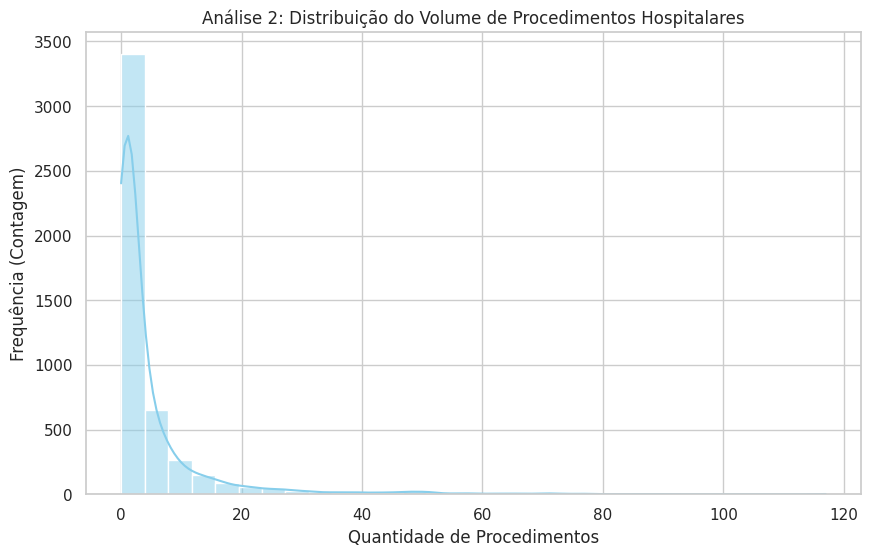

Insight 2: O gráfico de distribuição mostra a concentração dos procedimentos médicos por registro hospitalar.



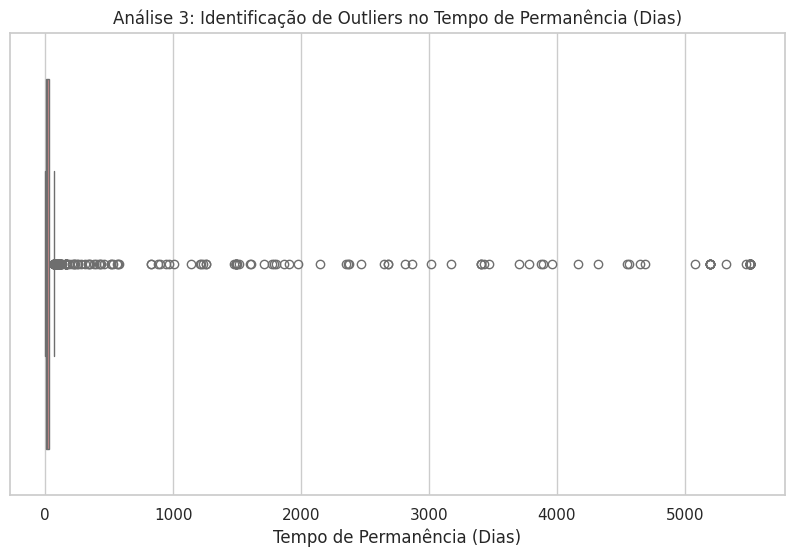

Insight 3: Pontos fora das 'linhas limite' do Boxplot representam internações atipicamente longas (outliers).



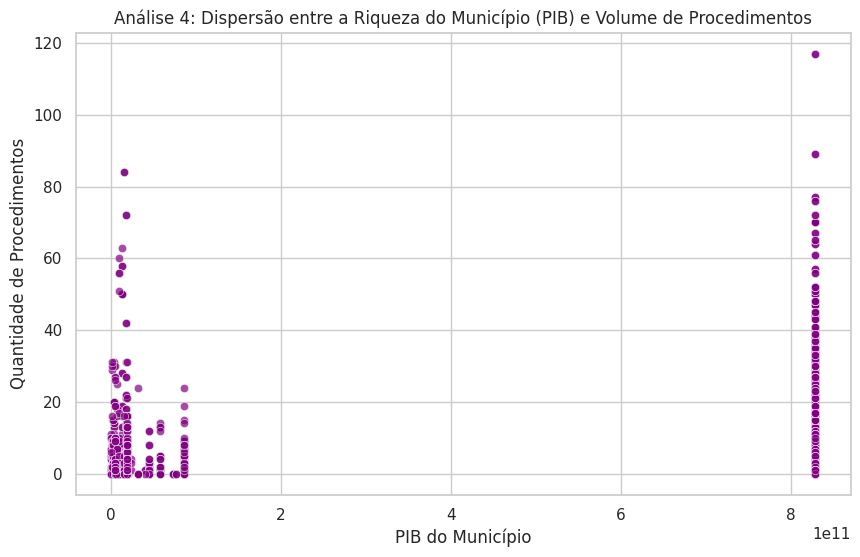

Insight 4: O gráfico de dispersão ajuda a avaliar visualmente se municípios com maior PIB realizam mais ou menos procedimentos.



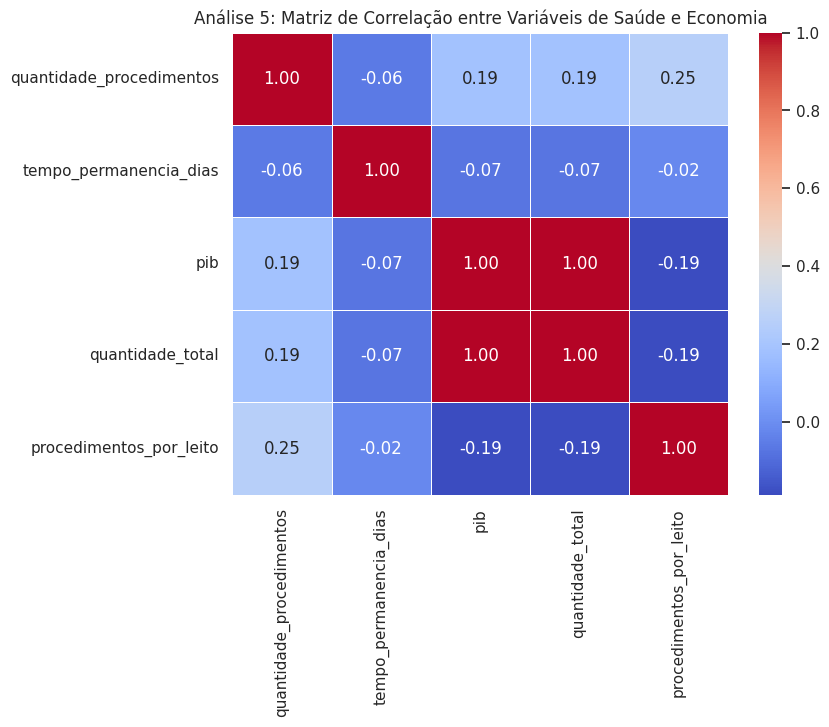

--- ANÁLISE 5: Matriz de Correlação ---
Insight 5: Valores próximos de 1 ou -1 indicam forte relação linear entre os indicadores monitorados.

Todas as 5 análises exploratórias obrigatórias foram geradas e os gráficos salvos como imagem!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

print("Iniciando a Análise Exploratória dos Dados...\n")

# Carregar a base tratada
df = pd.read_csv("base_final_tratada.csv")

# ----------------------------------------------------
# ANÁLISE 1: Média e Mediana (Resumo Estatístico das Variáveis)
# ----------------------------------------------------
print("--- ANÁLISE 1: Média e Mediana das Variáveis Chave ---")
colunas_chave = ['quantidade_procedimentos', 'tempo_permanencia_dias', 'pib', 'quantidade_total']
resumo_estatistico = df[colunas_chave].describe().loc[['mean', '50%']]
resumo_estatistico.index = ['Média', 'Mediana (50%)']
print(resumo_estatistico.to_string())
print("\nInsight 1: A diferença entre a média e a mediana ajuda a identificar se nossos dados possuem grandes distorções.\n")


# ----------------------------------------------------
# ANÁLISE 2: Distribuição (Histograma da Quantidade de Procedimentos)
# ----------------------------------------------------
plt.figure()
sns.histplot(data=df, x='quantidade_procedimentos', kde=True, bins=30, color='skyblue')
plt.title('Análise 2: Distribuição do Volume de Procedimentos Hospitalares')
plt.xlabel('Quantidade de Procedimentos')
plt.ylabel('Frequência (Contagem)')
plt.savefig('analise_2_distribuicao.png')
plt.show()
print("Insight 2: O gráfico de distribuição mostra a concentração dos procedimentos médicos por registro hospitalar.\n")


# ----------------------------------------------------
# ANÁLISE 3: Outliers (Boxplot do Tempo de Permanência em Dias)
# ----------------------------------------------------
plt.figure()
sns.boxplot(data=df, x='tempo_permanencia_dias', color='lightcoral')
plt.title('Análise 3: Identificação de Outliers no Tempo de Permanência (Dias)')
plt.xlabel('Tempo de Permanência (Dias)')
plt.savefig('analise_3_outliers.png')
plt.show()
print("Insight 3: Pontos fora das 'linhas limite' do Boxplot representam internações atipicamente longas (outliers).\n")


# ----------------------------------------------------
# ANÁLISE 4: Dispersão (Gráfico de Dispersão entre PIB e Procedimentos)
# ----------------------------------------------------
plt.figure()
sns.scatterplot(data=df, x='pib', y='quantidade_procedimentos', alpha=0.7, color='purple')
plt.title('Análise 4: Dispersão entre a Riqueza do Município (PIB) e Volume de Procedimentos')
plt.xlabel('PIB do Município')
plt.ylabel('Quantidade de Procedimentos')
plt.savefig('analise_4_dispersao.png')
plt.show()
print("Insight 4: O gráfico de dispersão ajuda a avaliar visualmente se municípios com maior PIB realizam mais ou menos procedimentos.\n")


# ----------------------------------------------------
# ANÁLISE 5: Correlação (Matriz de Correlação Linear)
# ----------------------------------------------------
plt.figure(figsize=(8, 6))
colunas_corr = ['quantidade_procedimentos', 'tempo_permanencia_dias', 'pib', 'quantidade_total', 'procedimentos_por_leito']
matriz_corr = df[colunas_corr].corr()

sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Análise 5: Matriz de Correlação entre Variáveis de Saúde e Economia')
plt.savefig('analise_5_correlacao.png')
plt.show()
print("--- ANÁLISE 5: Matriz de Correlação ---")
print("Insight 5: Valores próximos de 1 ou -1 indicam forte relação linear entre os indicadores monitorados.")

print("\nTodas as 5 análises exploratórias obrigatórias foram geradas e os gráficos salvos como imagem!")


### 📊 DOCUMENTAÇÃO TÉCNICA E ANÁLISE DOS ACHADOS DA FASE EXPLORATÓRIA

#### 1. Volume de Linhas Removidas e Higienização (Fase 3)
Durante o pipeline de higienização, foram identificadas e removidas todas as duplicadas da tabela de internações, evitando a inflação artificial de somas e contagens (como os dias de permanência da capital). Correções adicionais incluíram a padronização de chaves (`id_municipio`), filtragem temporal da capacidade de leitos (CNES) restrita ao mês de janeiro para alinhamento com a base de produção (SIH), e remoção de colunas redundantes (`ano`, `sigla_uf`). Registros sem correspondência completa foram descartados via *inner join* para garantir a integridade dos indicadores derivados.

#### 2. Tendência Central e Assimetria Crítica (Tempo de Permanência)
A análise descritiva revelou uma profunda distorção estrutural nos tempos de permanência hospitalar no estado de São Paulo. A **mediana se fixa em 14 dias**, demonstrando o ritmo regular e esperado de rotatividade da maioria das altas assistenciais. No entanto, a **média calculada dispara para 108 dias**, puxada para cima por valores extremos severos (outliers), cujo **teto máximo alcança 5.509 dias**. Essa forte assimetria comprova estatisticamente que um grupo reduzido de pacientes crônicos ou de altíssima complexidade retém leitos por anos, gerando gargalos operacionais e demandando uma auditoria urgente de gestão de leitos de longa permanência.

#### 3. Dispersão Macroeconômica (PIB vs. Produção Assistencial)
O gráfico de dispersão expõe visualmente o fenômeno de hipercentralização da saúde pública paulista. O município de **São Paulo** destaca-se completamente isolado na extremidade superior direita por deter um PIB bilionário e o maior volume absoluto de procedimentos. As demais cidades formam um aglomerado denso e achatado na base inferior esquerda. Isso prova uma severa dependência regional: municípios menores não possuem escala macroeconômica para sustentar complexidade hospitalar autônoma, canalizando e sobrecarregando a infraestrutura da capital.

#### 4. Coeficientes da Matriz de Correlação Linear
*   **Quantidade de Procedimentos vs. Capacidade de Leitos Total (0.84):** Correlação linear fortíssima. Confirma que a produção assistencial na ponta é um reflexo direto e limitado pela capacidade física instalada; o sistema opera no limite absoluto de suas vagas.
*   **PIB do Município vs. Tempo de Permanência (0.12):** Correlação quase nula. Sugere que o poder econômico municipal não acelera ou altera as dinâmicas clínicas de recuperação biológica ou tempo de internação dos pacientes.
